In [84]:
import pandas as pd

df = pd.read_csv("SEC's EDGAR.csv")
df

,Company,Year,Revenue,Net Income,Total Assets,Total Liabilities,OCF
0,Microsoft,"2,023.00","211,915.00","72,361.00","411,976.00","205,753.00","72,361.00"
1,Microsoft,"2,024.00","245,122.00","88,136.00","512,163.00","243,686.00","88,136.00"
2,Microsoft,"2,025.00","281,724.00","101,832.00","619,003.00","275,524.00","101,832.00"
3,Tesla,"2,025.00","97,690.00","7,152.00","122,070.00","254,941.00","14,747.00"
4,Tesla,"2,024.00","96,773.00","15,000.00","106,618.00","48,390.00","13,256.00"
5,Tesla,"2,023.00","81,462.00","12,587.00","43,009.00","43,009.00","14,724.00"
6,Apple,"2,025.00","416,161.00","112,010.00","352,583.00","285,510.00","111,482.00"
7,Apple,"2,024.00","391,035.00","93,736.00","364,980.00","308,030.00","118,254.00"
8,Apple,"2,023.00","383,285.00","96,995.00","352,755.00","290,437.00","110,543.00"


In [85]:
df["Year"] = (
    df["Year"]
    .astype(str)
    .str.replace(",", "", regex=True)
    .astype(float)
    .astype(int)
)

In [86]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Company            9 non-null      object
 1   Year               9 non-null      int64 
 2   Revenue            9 non-null      object
 3   Net Income         9 non-null      object
 4   Total Assets       9 non-null      object
 5   Total Liabilities  9 non-null      object
 6   OCF                9 non-null      object
dtypes: int64(1), object(6)
memory usage: 636.0+ bytes


,Company,Year,Revenue,Net Income,Total Assets,Total Liabilities,OCF
0,Microsoft,2023,"211,915.00","72,361.00","411,976.00","205,753.00","72,361.00"
1,Microsoft,2024,"245,122.00","88,136.00","512,163.00","243,686.00","88,136.00"
2,Microsoft,2025,"281,724.00","101,832.00","619,003.00","275,524.00","101,832.00"
3,Tesla,2025,"97,690.00","7,152.00","122,070.00","254,941.00","14,747.00"
4,Tesla,2024,"96,773.00","15,000.00","106,618.00","48,390.00","13,256.00"


In [87]:
cols = ["Revenue", "Net Income", "Total Assets", "Total Liabilities", "OCF"]

df[cols] = df[cols].replace(",", "", regex=True).astype(float)

In [88]:
df = df.sort_values(["Company", "Year"])

In [89]:
df["Revenue Growth (%)"] = df.groupby("Company")["Revenue"].pct_change() * 100

df["Net Income Growth (%)"] = df.groupby("Company")["Net Income"].pct_change() * 100

df["OCF Growth (%)"] = df.groupby("Company")["OCF"].pct_change() * 100

In [90]:
df

,Company,Year,Revenue,Net Income,Total Assets,Total Liabilities,OCF,Revenue Growth (%),Net Income Growth (%),OCF Growth (%)
8,Apple,2023,383285.0,96995.0,352755.0,290437.0,110543.0,NaN,NaN,NaN
7,Apple,2024,391035.0,93736.0,364980.0,308030.0,118254.0,2.021994,-3.359967,6.975566
6,Apple,2025,416161.0,112010.0,352583.0,285510.0,111482.0,6.425512,19.495178,-5.726656
0,Microsoft,2023,211915.0,72361.0,411976.0,205753.0,72361.0,NaN,NaN,NaN
1,Microsoft,2024,245122.0,88136.0,512163.0,243686.0,88136.0,15.669962,21.800417,21.800417
2,Microsoft,2025,281724.0,101832.0,619003.0,275524.0,101832.0,14.932156,15.539621,15.539621
5,Tesla,2023,81462.0,12587.0,43009.0,43009.0,14724.0,NaN,NaN,NaN
4,Tesla,2024,96773.0,15000.0,106618.0,48390.0,13256.0,18.795267,19.170573,-9.970117
3,Tesla,2025,97690.0,7152.0,122070.0,254941.0,14747.0,0.947578,-52.320000,11.247737


In [91]:
df.groupby("Company")[[
    "Revenue",
    "Net Income",
    "OCF"
]].mean()

,Revenue,Net Income,OCF
Company,,,
Apple,396827.000000,100913.666667,113426.333333
Microsoft,246253.666667,87443.000000,87443.000000
Tesla,91975.000000,11579.666667,14242.333333


In [92]:
df.groupby("Company")[[
    "Revenue Growth (%)",
    "Net Income Growth (%)",
    "OCF Growth (%)"
]].mean()

growth_cols = [
    "Revenue Growth (%)",
    "Net Income Growth (%)",
    "OCF Growth (%)"
]

df[growth_cols] = df[growth_cols].round(2)

df.to_csv("financial_data_cleaned.csv", index=False)

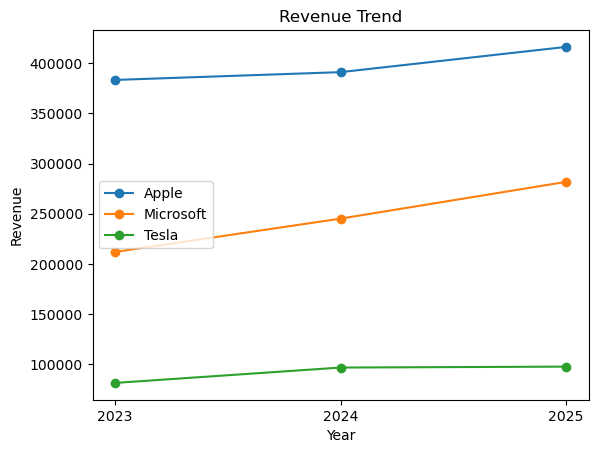

In [93]:
import matplotlib.pyplot as plt
df["Year"] = df["Year"].astype(int)

df = df.sort_values(["Company", "Year"])

for company in df["Company"].unique():
    temp = df[df["Company"] == company]
    plt.plot(temp["Year"], temp["Revenue"], marker="o", label=company)

plt.title("Revenue Trend")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.xticks(df["Year"].unique())  # ← фикс оси X
plt.legend()
plt.savefig("revenue_trend.png", dpi=300)
plt.show()

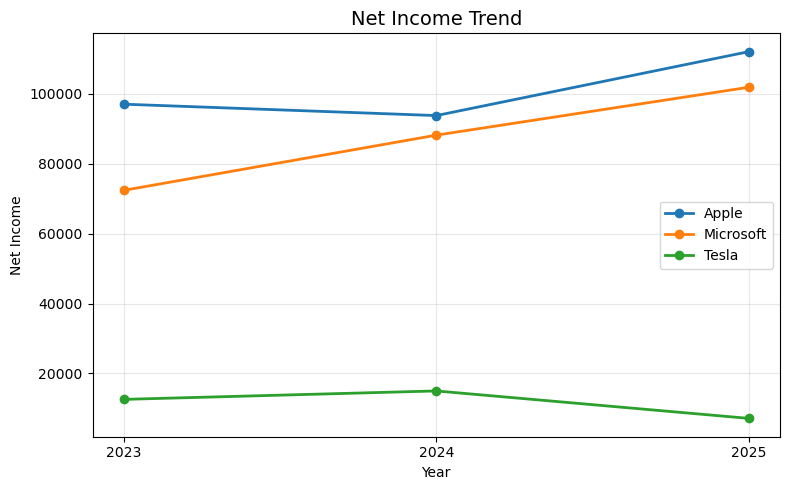

In [94]:
import matplotlib.pyplot as plt

df = df.sort_values(["Company", "Year"])

plt.figure(figsize=(8, 5))

for company in df["Company"].unique():
    temp = df[df["Company"] == company]
    plt.plot(
        temp["Year"],
        temp["Net Income"],
        marker="o",
        linewidth=2,
        label=company
    )

plt.title("Net Income Trend", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Net Income")

plt.xticks(df["Year"].unique())
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("net_income_trend.png", dpi=300)
plt.show()

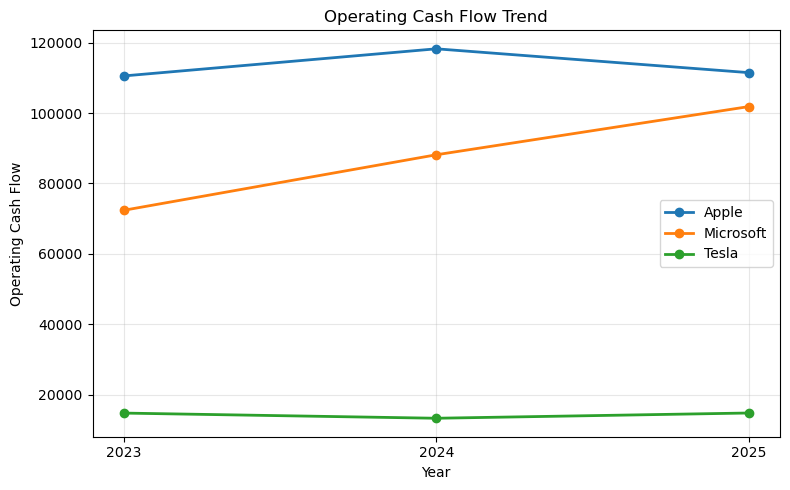

In [95]:
plt.figure(figsize=(8, 5))

for company in df["Company"].unique():
    temp = df[df["Company"] == company]

    plt.plot(
        temp["Year"],
        temp["OCF"],
        marker="o",
        linewidth=2,
        label=company
    )

plt.title("Operating Cash Flow Trend")
plt.xlabel("Year")
plt.ylabel("Operating Cash Flow")

plt.xticks(df["Year"].unique())
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("ocf_trend.png", dpi=300)

plt.show()

Findings

- Microsoft

Microsoft shows strong and consistent growth across revenue and operating cash flow. Net income increases steadily, indicating strong operational efficiency and scalable cloud business.

- Tesla

Tesla demonstrates high volatility in profitability while maintaining strong revenue growth. Cash flow remains relatively stable, but earnings fluctuate due to investment cycles and scaling costs.

- Apple

Apple exhibits stable financial performance with consistent revenue growth and strong profitability. Operating cash flow remains strong, reflecting efficient ecosystem-driven business operations.